<a href="https://colab.research.google.com/github/manusiele/student_score_prediction/blob/main/Copy_of_student_score_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Student Score Prediction — Feedforward Neural Network

**Dataset:** [Student Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams) + [Student Performance Data Set (G1/G2 → G3)](https://www.kaggle.com/datasets/larsen0966/student-performance-data-set)



**Architecture:** Feedforward Neural Network (Multi-layer Perceptron) built with PyTorch.



##  Setup — Install dependencies & mount Drive

In [ ]:
# Install kaggle API
!pip install kaggle --quiet

import os, json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {DEVICE}')

PyTorch version : 2.10.0+cu128
CUDA available  : True
Using device    : cuda


##  Kaggle Authentication

> **Setup Kaggle Secrets in Colab:**
> 1. Go to https://www.kaggle.com → Account → **Create New API Token**
> 2. Open the downloaded `kaggle.json` file
> 3. In Colab: Click the  key icon (Secrets) in the left sidebar
> 4. Add two secrets:
>    - Name: `KAGGLE_USERNAME` → Value: your username from kaggle.json
>    - Name: `KAGGLE_KEY` → Value: your key from kaggle.json
> 5. Enable notebook access for both secrets

In [ ]:
from google.colab import files

print('Upload your kaggle.json ...')
uploaded = files.upload()   # <- select kaggle.json here

# Move to expected location
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded['kaggle.json'])
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('kaggle.json configured.')

Upload your kaggle.json ...


Saving kaggle.json to kaggle.json
kaggle.json configured.


##  Download Kaggle Datasets

In [37]:
# ── Dataset 1: Students Performance in Exams (math / reading / writing scores)
!kaggle datasets download -d spscientist/students-performance-in-exams -p /data/exams --unzip -q

# ── Dataset 2: Student Performance (G1, G2 → predict G3 final grade)
!kaggle datasets download -d larsen0966/student-performance-data-set -p /data/grades --unzip -q

print('Downloads complete.')
print('\nExams dataset files:')
!ls /data/exams
print('\nGrades dataset files:')
!ls /data/grades

Dataset URL: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
License(s): unknown
Dataset URL: https://www.kaggle.com/datasets/larsen0966/student-performance-data-set
License(s): CC0-1.0
Downloads complete.

Exams dataset files:
StudentsPerformance.csv

Grades dataset files:
student-por.csv


##  Load & Explore the Data

We use **both** datasets:
- **Dataset A** — `StudentsPerformance.csv`: demographic info + scores in math, reading, writing. Target = average score.
- **Dataset B** — `student-mat.csv`: period grades G1, G2 + 30 features. Target = **G3** (final grade).

In [39]:
import pandas as pd
import numpy as np

# ── Load Dataset A
df_a = pd.read_csv('/data/exams/StudentsPerformance.csv')
print('Dataset A shape:', df_a.shape)
df_a.head()

Dataset A shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Visualisations

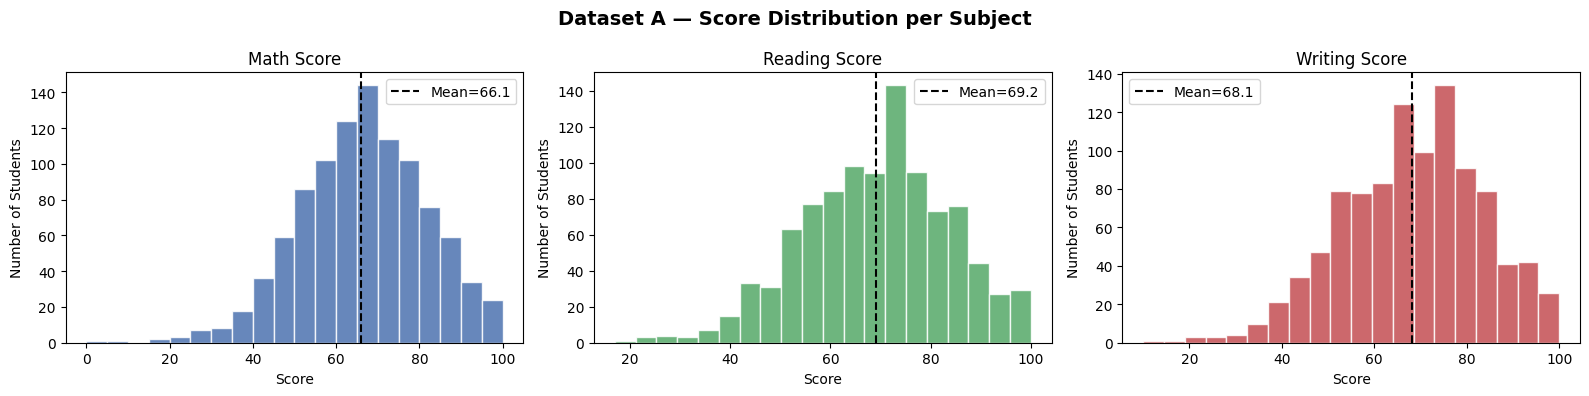

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Dataset A — Score Distribution per Subject', fontsize=14, fontweight='bold')

subjects = [
    ('math score',    'Math',    '#4C72B0'),
    ('reading score', 'Reading', '#55A868'),
    ('writing score', 'Writing', '#C44E52'),
]

for ax, (col, label, color) in zip(axes, subjects):
    ax.hist(df_a[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df_a[col].mean(), color='black', linestyle='--', label=f'Mean={df_a[col].mean():.1f}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Number of Students')
    ax.set_title(f'{label} Score')
    ax.legend()

plt.tight_layout()
plt.show()

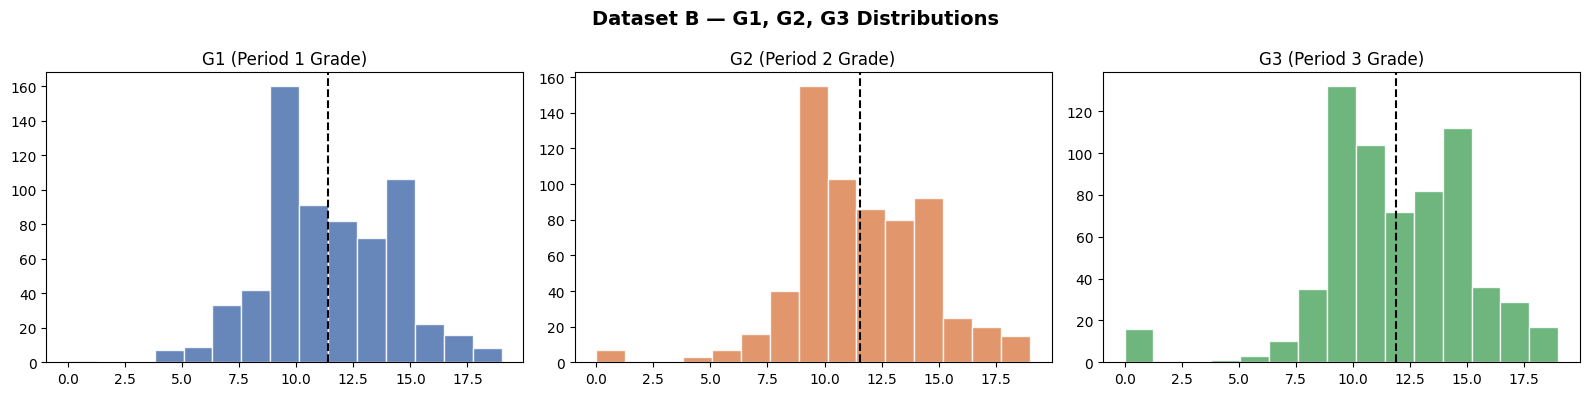

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Dataset B — G1, G2, G3 Distributions', fontsize=14, fontweight='bold')

for ax, col, color in zip(axes, ['G1', 'G2', 'G3'],
                           ['#4C72B0', '#DD8452', '#55A868']):
    ax.hist(df_b[col], bins=15, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df_b[col].mean(), color='black', linestyle='--')
    ax.set_title(f'{col} (Period {col[1]} Grade)')

plt.tight_layout()
plt.show()

Using separator: ','
df_b shape: (649, 33)
Numeric columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


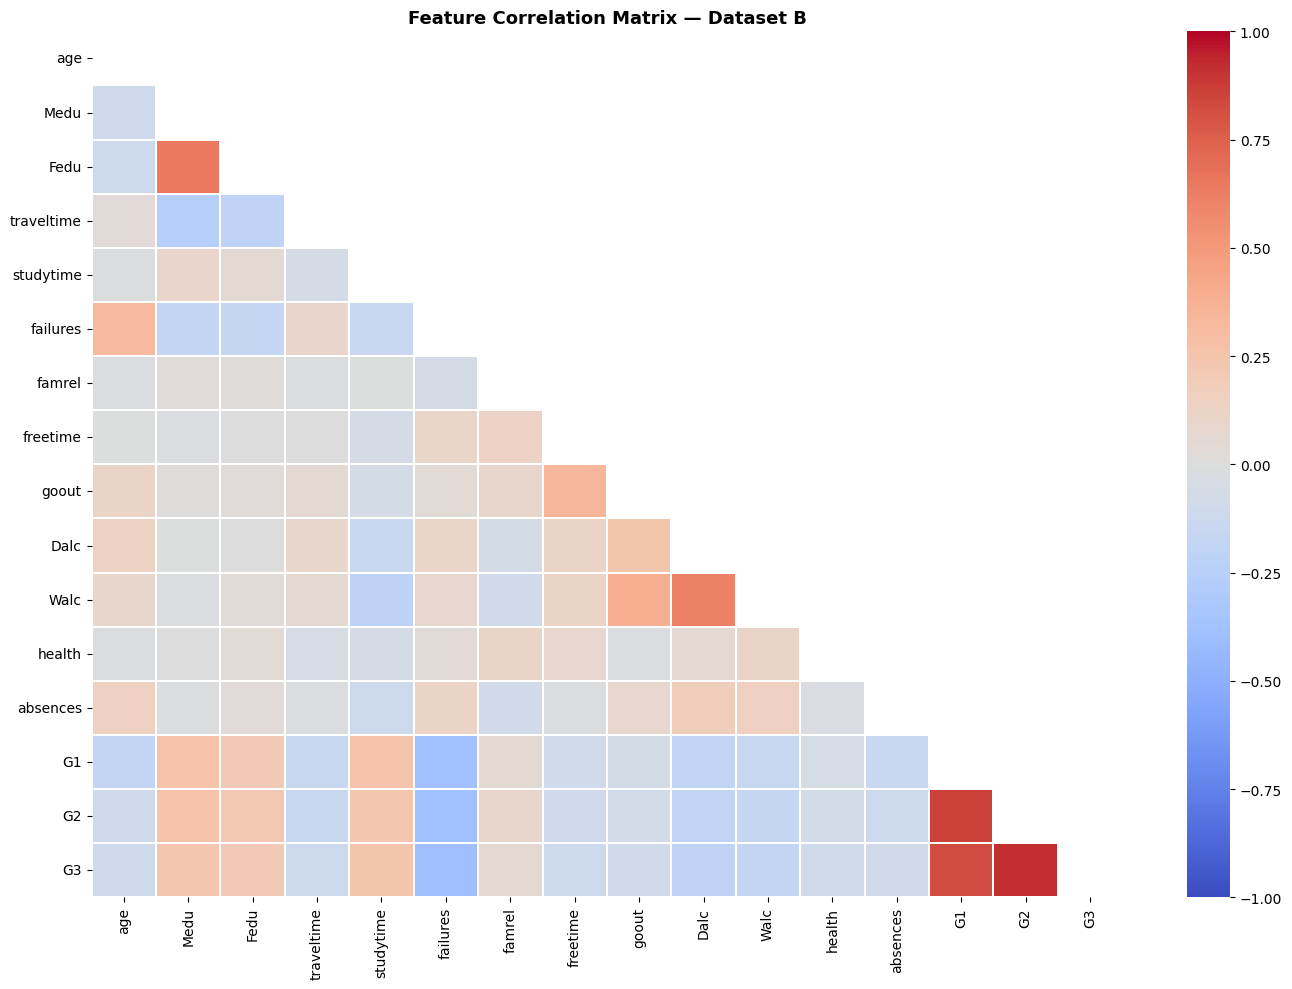

In [17]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO

# ── Fix df_b first ──
with open('/content/data/student-por.csv', 'r') as f:
    raw = f.read()

# Detect real delimiter
first_line = raw.split('\n')[0]
sep = ',' if (raw.count(',') > raw.count(';')) else ';'
print(f'Using separator: {repr(sep)}')

df_b = pd.read_csv(StringIO(raw), sep=sep)

# If still 1 column, the header itself is comma-joined inside a single field
if df_b.shape[1] == 1:
    col_name = df_b.columns[0]
    headers = col_name.split(',')
    rows = [row[0].split(',') for _, row in df_b.iterrows()]
    df_b = pd.DataFrame(rows, columns=headers)
    numeric_cols = ['age','Medu','Fedu','traveltime','studytime','failures',
                    'famrel','freetime','goout','Dalc','Walc','health','absences',
                    'G1','G2','G3']
    for col in numeric_cols:
        df_b[col] = pd.to_numeric(df_b[col], errors='coerce')

print(f'df_b shape: {df_b.shape}')
print(f'Numeric columns: {list(df_b.select_dtypes(include="number").columns)}')

# ── Now draw the heatmap ──
plt.figure(figsize=(14, 10))
corr = df_b.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix — Dataset B', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##  Pre-processing

### 4A — Dataset A  
Target = **average of math + reading + writing scores** (future overall score)

In [19]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

df_a = df_a.copy()

# Target: average score
df_a['avg_score'] = df_a[['math score', 'reading score', 'writing score']].mean(axis=1)

# Encode categoricals
cat_cols_a = ['gender', 'race/ethnicity', 'parental level of education',
              'lunch', 'test preparation course']
le = LabelEncoder()
for col in cat_cols_a:
    df_a[col] = le.fit_transform(df_a[col])

FEATURES_A = ['gender', 'race/ethnicity', 'parental level of education',
               'lunch', 'test preparation course',
               'math score', 'reading score']
TARGET_A   = 'writing score'

X_a = df_a[FEATURES_A].values.astype(np.float32)
y_a = df_a[TARGET_A].values.astype(np.float32)

print(f'Dataset A  —  X: {X_a.shape}, y: {y_a.shape}')
print(f'Predicting: {TARGET_A}')

Dataset A  —  X: (1000, 7), y: (1000,)
Predicting: writing score


### 4B — Dataset B  
Target = **G3** (final grade), inputs include G1, G2 + 30 other features

In [21]:
df_b = df_b.copy()

# Encode binary/categorical string columns
for col in df_b.select_dtypes(include='object').columns:
    df_b[col] = LabelEncoder().fit_transform(df_b[col])

TARGET_B   = 'G3'
FEATURES_B = [c for c in df_b.columns if c != TARGET_B]

X_b = df_b[FEATURES_B].values.astype(np.float32)
y_b = df_b[TARGET_B].values.astype(np.float32)

print(f'Dataset B  —  X: {X_b.shape}, y: {y_b.shape}')
print(f'Input features ({len(FEATURES_B)}): {FEATURES_B}')

Dataset B  —  X: (649, 32), y: (649,)
Input features (32): ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# ── Build X_b, y_b from the fixed df_b ──
FEATURES_B = ['G1', 'G2', 'age', 'Medu', 'Fedu', 'studytime', 'failures', 'absences']
TARGET_B   = 'G3'

X_b = df_b[FEATURES_B].values.astype(np.float32)
y_b = df_b[TARGET_B].values.astype(np.float32)
print(f'Dataset B  —  X: {X_b.shape}, y: {y_b.shape}')

# ── Choose dataset ──
X_raw, y_raw, dataset_name = X_b, y_b, 'Dataset B (G1+G2 → G3)'

# ── Split 70 / 15 / 15 ──
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_raw, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

# ── Standardise ──
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Using: {dataset_name}')
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Dataset B  —  X: (649, 8), y: (649,)
Using: Dataset B (G1+G2 → G3)
Train: (454, 8) | Val: (97, 8) | Test: (98, 8)


In [25]:
import torch
from torch.utils.data import DataLoader, TensorDataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Convert to PyTorch tensors
def to_tensor(X, y):
    return (torch.tensor(X, dtype=torch.float32).to(DEVICE),
            torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(DEVICE))

X_tr, y_tr = to_tensor(X_train, y_train)
X_vl, y_vl = to_tensor(X_val,   y_val)
X_te, y_te = to_tensor(X_test,  y_test)

BATCH = 32
train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_vl, y_vl), batch_size=BATCH)

print(f'Device: {DEVICE}')
print(f'Batches per epoch: {len(train_loader)}')

Device: cuda
Batches per epoch: 15


##  Build the Feedforward Neural Network

In [27]:
import torch.nn as nn

class StudentFNN(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

INPUT_DIM = X_train.shape[1]
model     = StudentFNN(INPUT_DIM).to(DEVICE)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

StudentFNN(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=16, bias=True)
    (12): ReLU()
    (13): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total parameters: 12,481


## Train with Early Stopping

In [29]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10)

EPOCHS        = 300
PATIENCE      = 25
best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = None
history       = {'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * Xb.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_loss += criterion(model(Xb), yb).item() * Xb.size(0)
    val_loss /= len(val_loader.dataset)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    scheduler.step(val_loss)

    if epoch % 25 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr  = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}. Best val MSE: {best_val_loss:.4f}')
            break

model.load_state_dict(best_weights)
print('Training complete. Best weights restored.')

Epoch  25/300 | Train MSE: 2.7884 | Val MSE: 1.7931
Epoch  50/300 | Train MSE: 2.3109 | Val MSE: 1.4260
Epoch  75/300 | Train MSE: 2.4453 | Val MSE: 1.2542
Epoch 100/300 | Train MSE: 1.9165 | Val MSE: 1.2431

Early stopping at epoch 101. Best val MSE: 1.1038
Training complete. Best weights restored.


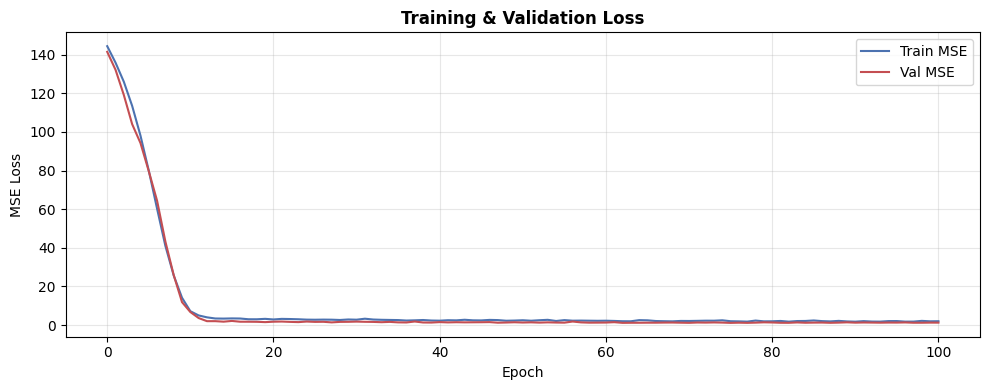

In [30]:
# ── Loss curves
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train MSE', color='#4C72B0')
plt.plot(history['val_loss'],   label='Val MSE',   color='#C44E52')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##  Evaluate on Test Set

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model.eval()
with torch.no_grad():
    y_pred = model(X_te).cpu().numpy().flatten()

y_true = y_test

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print('=' * 40)
print('  Test Set Evaluation Results')
print('=' * 40)
print(f'  MAE  : {mae:.3f}  (avg pts off)')
print(f'  RMSE : {rmse:.3f}')
print(f'  R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)')
print('=' * 40)

  Test Set Evaluation Results
  MAE  : 0.852  (avg pts off)
  RMSE : 1.417
  R²   : 0.8335  (83.3% variance explained)


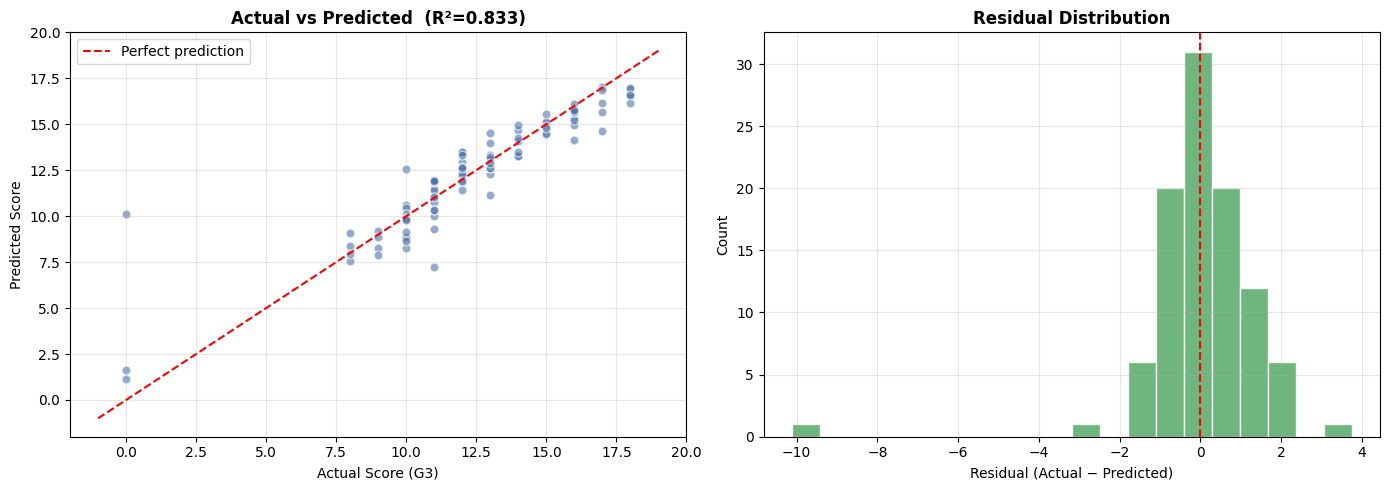

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Actual vs Predicted
axes[0].scatter(y_true, y_pred, alpha=0.6, color='#4C72B0', edgecolors='white', s=40)
lim = [min(y_true.min(), y_pred.min()) - 1, max(y_true.max(), y_pred.max()) + 1]
axes[0].plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Score (G3)')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.3f})', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Residuals
residuals = y_true - y_pred
axes[1].hist(residuals, bins=20, color='#55A868', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Predict a New Student's Score

Fill in the values below to predict a student's **G3 (final grade)**.

> Features match the student-mat.csv columns (G1 and G2 are the most impactful — try different values!).

In [38]:
import torch
import numpy as np

student_marks = {
    'Math'      : 75,
    'English'   : 68,
    'Science'   : 80,
    'History'   : 55,
    'Geography' : 60,
    'Physics'   : 72,
    'Chemistry' : 65,
    'Biology'   : 70,
}

marks_scaled = [round((m / 100) * 20, 2) for m in student_marks.values()]

student_arr = scaler.transform([marks_scaled])
student_t   = torch.tensor(student_arr, dtype=torch.float32).to(DEVICE)

model.eval()
with torch.no_grad():
    predicted_score = model(student_t).item()

predicted_score = max(0, min(20, predicted_score))
predicted_pct   = (predicted_score / 20) * 100

print('=' * 45)
print('       🎓  Student Score Prediction')
print('=' * 45)
for subject, mark in student_marks.items():
    print(f'  {subject:<12} : {mark}%')
print('  ─────────────────────────────────────')
print(f'  Predicted Score : {predicted_score:.2f} / 20  ({predicted_pct:.1f}%)')
print(f'  Status          : {"✓ Pass" if predicted_score >= 10 else "✗ Fail"}')
print('=' * 45)

       🎓  Student Score Prediction
  Math         : 75%
  English      : 68%
  Science      : 80%
  History      : 55%
  Geography    : 60%
  Physics      : 72%
  Chemistry    : 65%
  Biology      : 70%
  ─────────────────────────────────────
  Predicted Score : 13.27 / 20  (66.3%)
  Status          : ✓ Pass
